Link to the dataset: https://www.kaggle.com/datasets/sayankr007/cyber-bullying-data-for-multi-label-classification

I have the Processed and Labelled version of The Dataset Converted from CSV version of the Original hateXplain Dataset



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv('final_hateXplain.csv')
df['Miscellaneous'] = df['Miscellaneous'].fillna('None')

In [ ]:
#Defining "Double Marginalization" (Intersectionality)
#Target is a Woman AND belongs to another minority group
def is_minority(row):
    # Checks if any identity marker other than gender is present
    has_race = row['Race'] != 'No_race'
    has_religion = row['Religion'] != 'Nonreligious'
    has_orientation = row['Sexual Orientation'] != 'No_orientation'
    has_misc = row['Miscellaneous'] not in ['None', 'Other']
    return any([has_race, has_religion, has_orientation, has_misc])

df['is_minority'] = df.apply(is_minority, axis=1)
df['intersectional_women'] = (df['Gender'] == 'Women') & (df['is_minority'] == True)

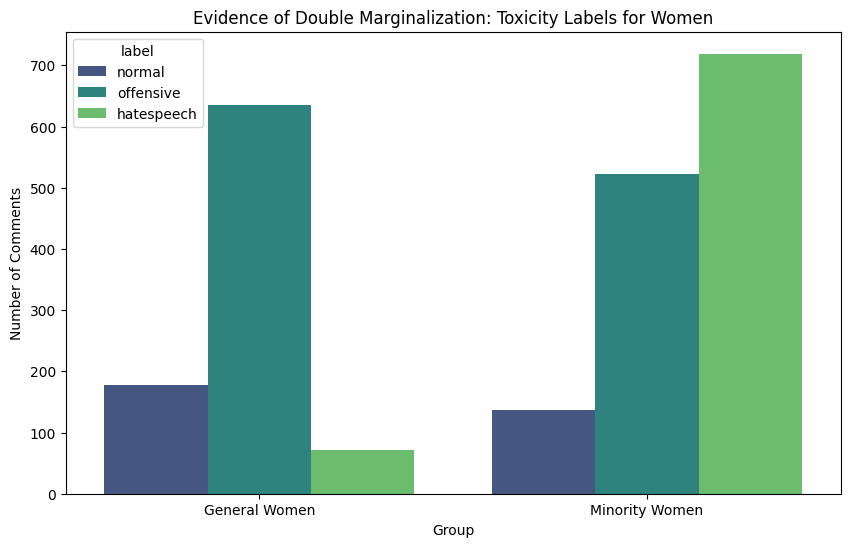

In [ ]:
# Visualization: Toxicity Distribution
# Comparing General Women vs. Intersectional (Minority) Women
women_df = df[df['Gender'] == 'Women'].copy()
women_df['Group'] = women_df['is_minority'].map({True: 'Minority Women', False: 'General Women'})

plt.figure(figsize=(10, 6))
sns.countplot(data=women_df, x='Group', hue='label', palette='viridis')
plt.title('Evidence of Double Marginalization: Toxicity Labels for Women')
plt.ylabel('Number of Comments')
plt.show()

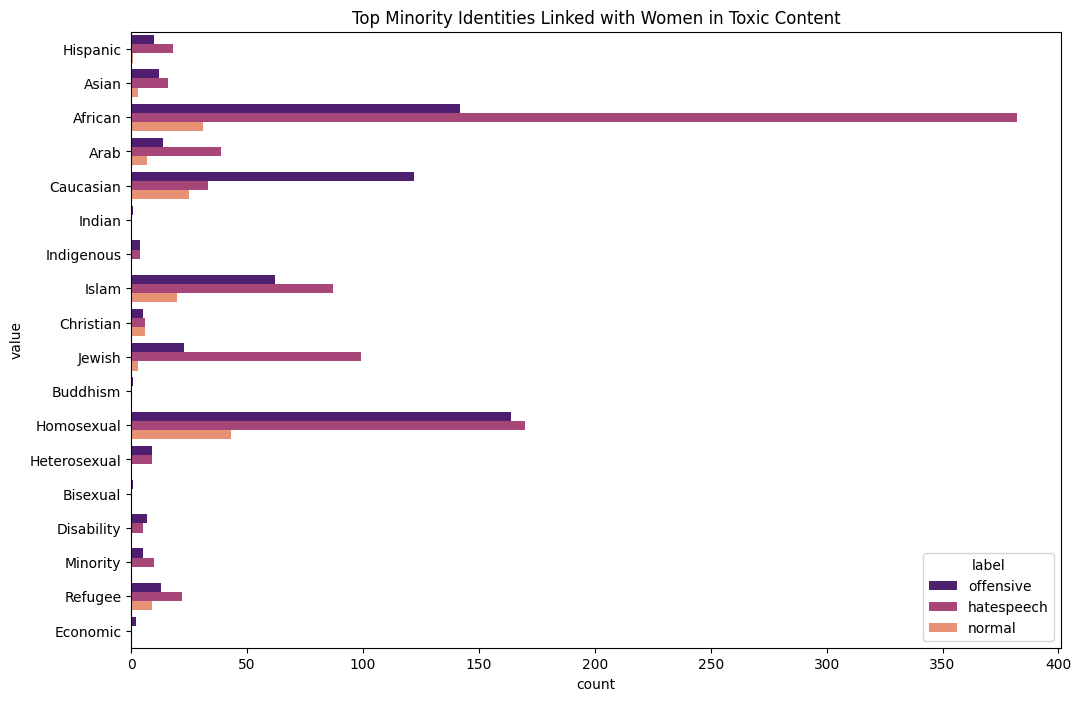

In [ ]:
# Visualization: Top Intersectional Identities
# Breakdown of which minority identities are most targeted when the victim is a woman
intersectional_women_df = df[df['intersectional_women']]
melted = pd.melt(intersectional_women_df, id_vars=['label'],
                 value_vars=['Race', 'Religion', 'Sexual Orientation', 'Miscellaneous'])
melted = melted[~melted['value'].isin(['No_race', 'Nonreligious', 'No_orientation', 'None', 'Other'])]

plt.figure(figsize=(12, 8))
sns.countplot(data=melted, y='value', hue='label', palette='magma')
plt.title('Top Minority Identities Linked with Women in Toxic Content')
plt.show()

--- Absolute Counts of Intersectional Groups ---
intersection_category
Minority (No Gender Specified)       8935
Neutral / No Minority ID             7445
Marginalized Women (Intersection)    1204
Women (Gender Only)                  1058
Marginalized Men (Intersection)       846
Men (Gender Only)                     621
Name: count, dtype: int64

--- Label Proportions by Group (%) ---
label                              hatespeech     normal  offensive
intersection_category                                              
Marginalized Men (Intersection)     52.718676   8.510638  38.770686
Marginalized Women (Intersection)   57.807309   8.887043  33.305648
Men (Gender Only)                    5.152979  64.251208  30.595813
Minority (No Gender Specified)      55.612759  13.945159  30.442082
Neutral / No Minority ID             3.317663  77.730020  18.952317
Women (Gender Only)                  8.884688  19.565217  71.550095

--- Average Comment Length ---
intersection_category
Marginalized 

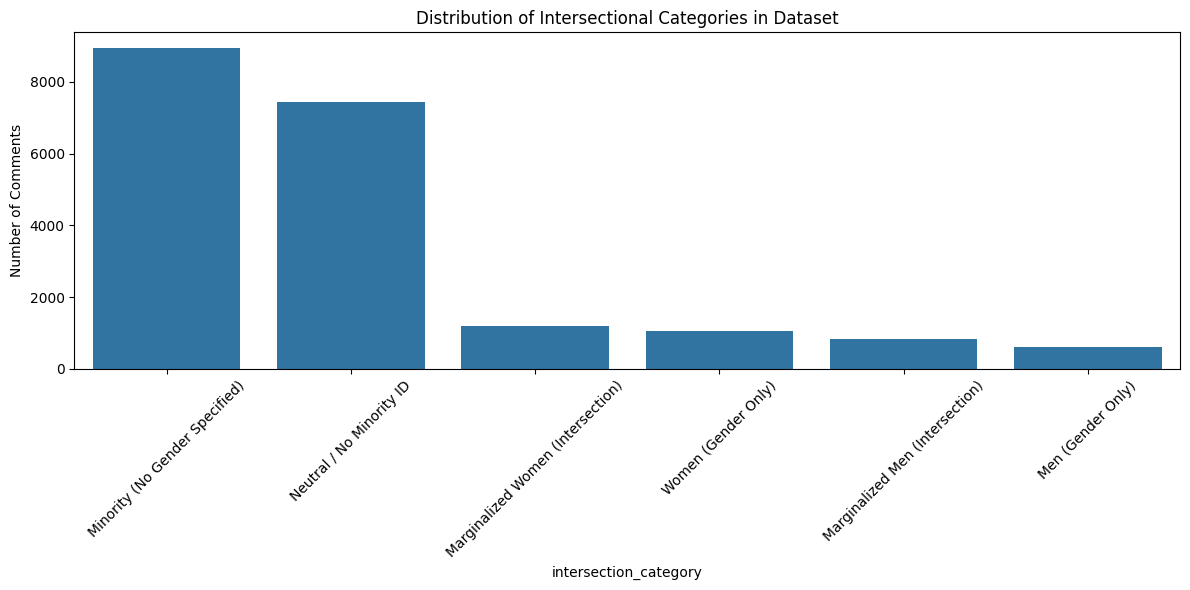

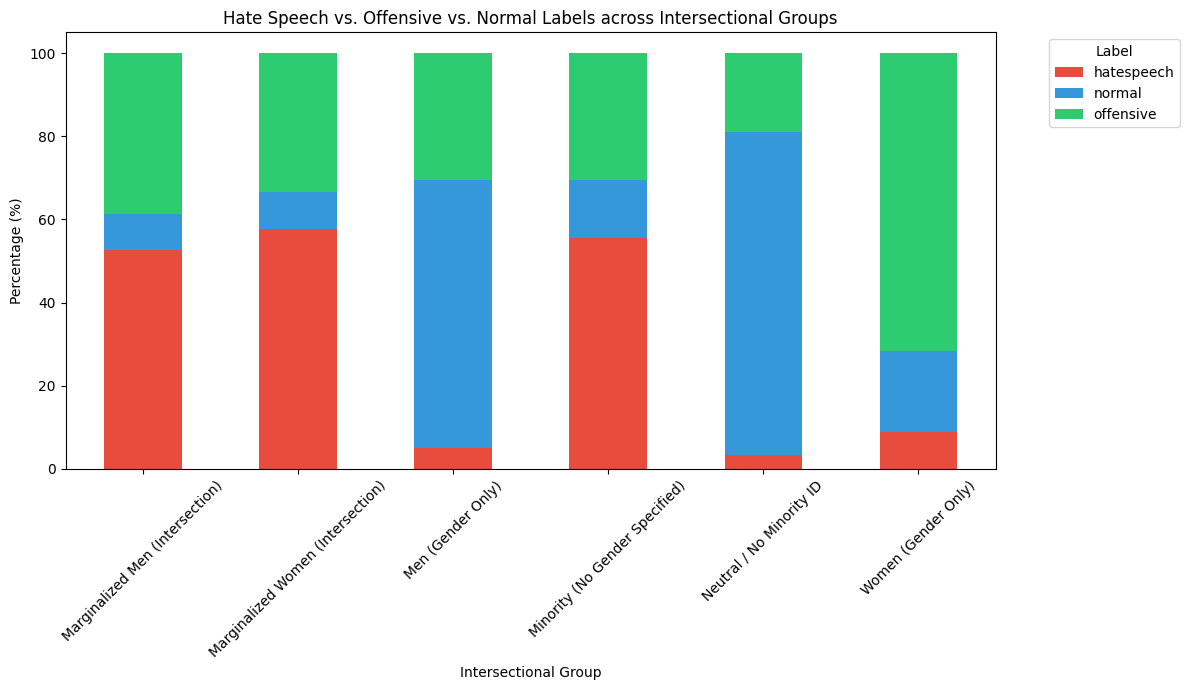

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Ensure 'final_hateXplain.csv' is in your working directory
df = pd.read_csv('final_hateXplain.csv')

# 2. Data Cleaning & Preparation
# Handle potential NaN values in 'Miscellaneous' and ensure all columns are strings
df['Miscellaneous'] = df['Miscellaneous'].fillna('None')

# 3. Define Intersectional Categories
# We categorize individuals based on the overlap of gender and other marginalized identities
minority_races = ['African', 'Asian', 'Hispanic', 'Arab', 'Indian', 'Indigenous']
minority_religions = ['Jewish', 'Islam', 'Hindu', 'Buddhism']
minority_orientations = ['Homosexual', 'Asexual', 'Bisexual']

def categorize_intersection(row):
    is_woman = row['Gender'] == 'Women'
    is_man = row['Gender'] == 'Men'

    # Identify if the comment targets a minority group (Race, Religion, Orientation, or Misc)
    has_minority_race = row['Race'] in minority_races
    has_minority_religion = row['Religion'] in minority_religions
    has_minority_orientation = row['Sexual Orientation'] in minority_orientations
    has_misc = row['Miscellaneous'] not in ['None', 'Other'] # 'Other' is often generic

    is_minority = has_minority_race or has_minority_religion or has_minority_orientation or has_misc

    if is_woman and not is_minority:
        return 'Women (Gender Only)'
    elif is_woman and is_minority:
        return 'Marginalized Women (Intersection)'
    elif is_man and is_minority:
        return 'Marginalized Men (Intersection)'
    elif is_man and not is_minority:
        return 'Men (Gender Only)'
    elif is_minority:
        return 'Minority (No Gender Specified)'
    else:
        return 'Neutral / No Minority ID'

# Apply categorization
df['intersection_category'] = df.apply(categorize_intersection, axis=1)

# 4. Exploratory Data Analysis (EDA)

# A. Frequency of Intersectional Groups
print("--- Absolute Counts of Intersectional Groups ---")
print(df['intersection_category'].value_counts())

# B. Proportion of Hate Speech/Offensive/Normal labels per group
# This helps identify bias and double marginalization
group_label_prop = pd.crosstab(df['intersection_category'], df['label'], normalize='index') * 100
print("\n--- Label Proportions by Group (%) ---")
print(group_label_prop)

# C. Average Comment Length (to check for complexity differences)
df['comment_length'] = df['comment'].str.split().str.len()
print("\n--- Average Comment Length ---")
print(df.groupby('intersection_category')['comment_length'].mean())

# 5. Visualizations

# Visualization 1: Distribution of Intersectional Categories
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='intersection_category', order=df['intersection_category'].value_counts().index)
plt.title('Distribution of Intersectional Categories in Dataset')
plt.xticks(rotation=45)
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.savefig('intersection_distribution.png')

# Visualization 2: Label Proportions (The "Double Marginalization" Graph)
group_label_prop.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Hate Speech vs. Offensive vs. Normal Labels across Intersectional Groups')
plt.ylabel('Percentage (%)')
plt.xlabel('Intersectional Group')
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('label_proportions_by_group.png')

# 6. Deep Dive: Normal Women vs. Marginalized Women
comparison_women = group_label_prop.loc[['Women (Gender Only)', 'Marginalized Women (Intersection)']]
print("\n--- Comparison: Normal Women vs Marginalized Women ---")
print(comparison_women)

# 7. Deep Dive: Marginalized Women vs. Marginalized Men
comparison_gender_minority = group_label_prop.loc[['Marginalized Women (Intersection)', 'Marginalized Men (Intersection)']]
print("\n--- Comparison: Marginalized Women vs Marginalized Men ---")
print(comparison_gender_minority)

# Export results for documentation
group_label_prop.to_csv('intersectional_analysis_results.csv')